<a href="https://colab.research.google.com/github/JesusRosales70/Machine-Learning/blob/main/Unidad%202/Pr%C3%A1ctica_3_ModelosRegresi%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine y Deep Learning
# Unidad 2
## Práctica 3: **Arboles de Regresión**
### Docente: Dr. Jose Gabriel Rodriguez Rivas
### Alumno: Jesus Armando Rosales Martinez

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score


df = pd.read_csv("autos2.csv")
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,peak-rpm,city-mpg,highway-L/100km,price,city-L/100km,fuel-type_code,diesel,gas,fuel-type-map,horsepower-binned
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,13495.0,11.190476,1,False,True,1,Low
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,16500.0,11.190476,1,False,True,1,Low
2,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,5000.0,19,9.038462,16500.0,12.368421,1,False,True,1,Medium
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,5500.0,24,7.833333,13950.0,9.791667,1,False,True,1,Low
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,5500.0,18,10.681818,17450.0,13.055556,1,False,True,1,Low


In [3]:
X = df[['horsepower', 'engine-size', 'city-mpg', 'wheel-base', 'bore']]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
tree_model = DecisionTreeRegressor(random_state=42, max_depth=4)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

mse_tree = mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)

print(f"Error cuadrático medio (MSE): {mse_tree:.2f}")
print(f"Coeficiente de determinación (R²): {r2_tree:.2f}")

Error cuadrático medio (MSE): 9188294.38
Coeficiente de determinación (R²): 0.92


In [5]:
import numpy as np
rmse = np.sqrt(mse_tree)
print(rmse)

3031.219949198344


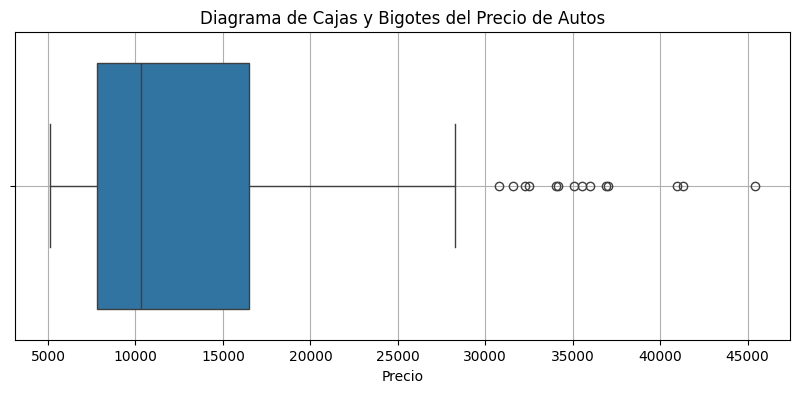

In [6]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df["price"])

plt.title("Diagrama de Cajas y Bigotes del Precio de Autos")
plt.xlabel("Precio")
plt.grid(True)
plt.show()

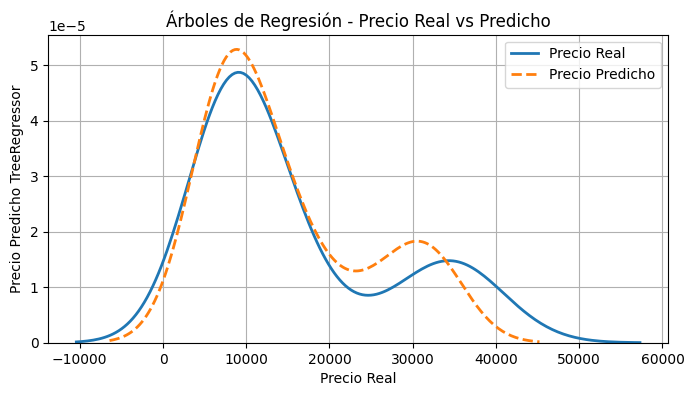

In [7]:
plt.figure(figsize=(8, 4))

sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred_tree, label='Precio Predicho', linewidth=2, linestyle='--')

plt.title('Árboles de Regresión - Precio Real vs Predicho')
plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho TreeRegressor')
plt.legend()
plt.grid(True)
plt.show()




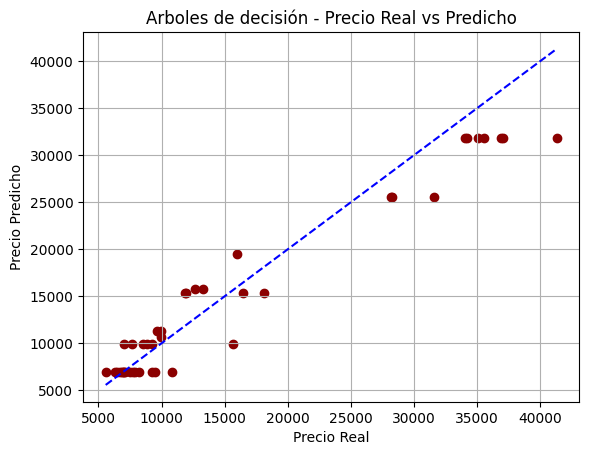

In [8]:
plt.scatter(y_test, y_pred_tree, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--')  # Línea ideal
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Arboles de decisión - Precio Real vs Predicho")
plt.grid(True)
plt.show()


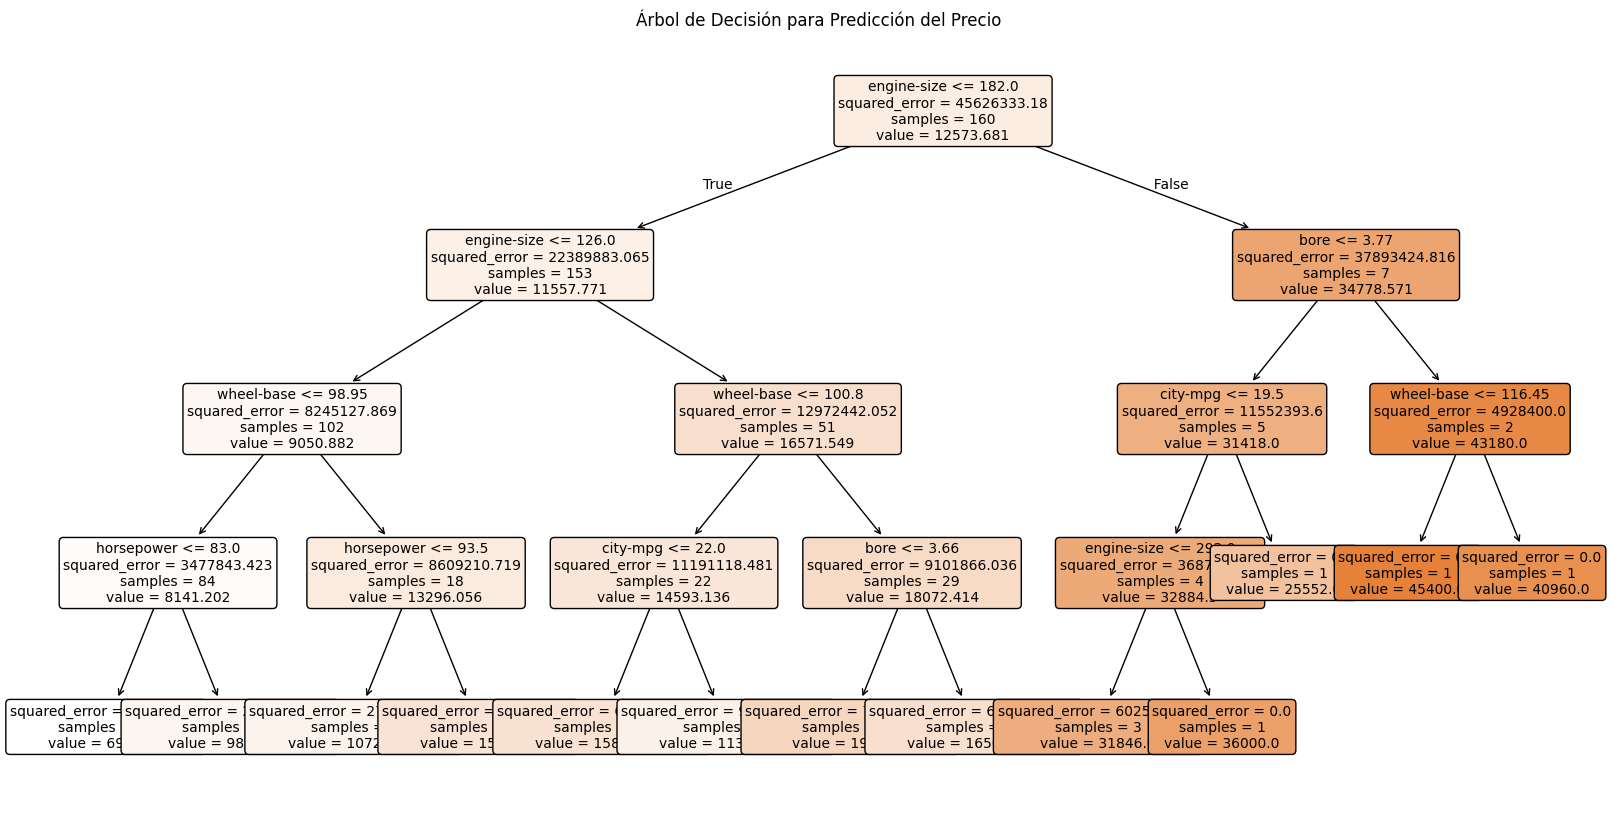

In [9]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(tree_model, feature_names=X.columns, filled=True, rounded=True, fontsize=10)
plt.title("Árbol de Decisión para Predicción del Precio")
plt.show()


Error cuadrático medio (MSE): 7896468.85
Coeficiente de determinación (R²): 0.94
RMSE: 2810.07


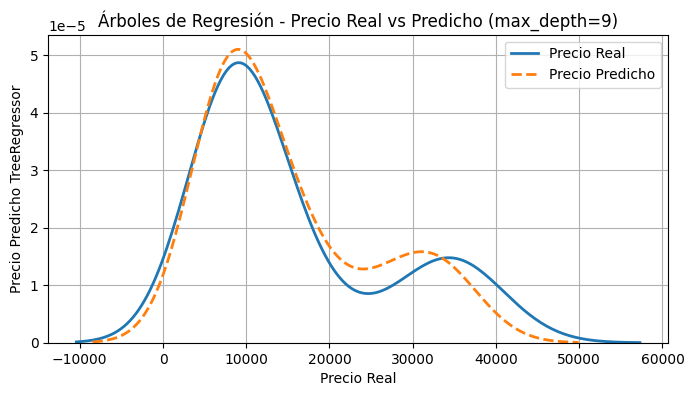

In [10]:
tree_model_9 = DecisionTreeRegressor(random_state=42, max_depth=9)
tree_model_9.fit(X_train, y_train)

y_pred_9 = tree_model_9.predict(X_test)

mse_9 = mean_squared_error(y_test, y_pred_9)
r2_9 = r2_score(y_test, y_pred_9)
rmse_9 = np.sqrt(mse_9)

print(f"Error cuadrático medio (MSE): {mse_9:.2f}")
print(f"Coeficiente de determinación (R²): {r2_9:.2f}")
print(f"RMSE: {rmse_9:.2f}")

plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred_9, label='Precio Predicho', linewidth=2, linestyle='--')
plt.title('Árboles de Regresión - Precio Real vs Predicho (max_depth=9)')
plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho TreeRegressor')
plt.legend()
plt.grid(True)
plt.show()




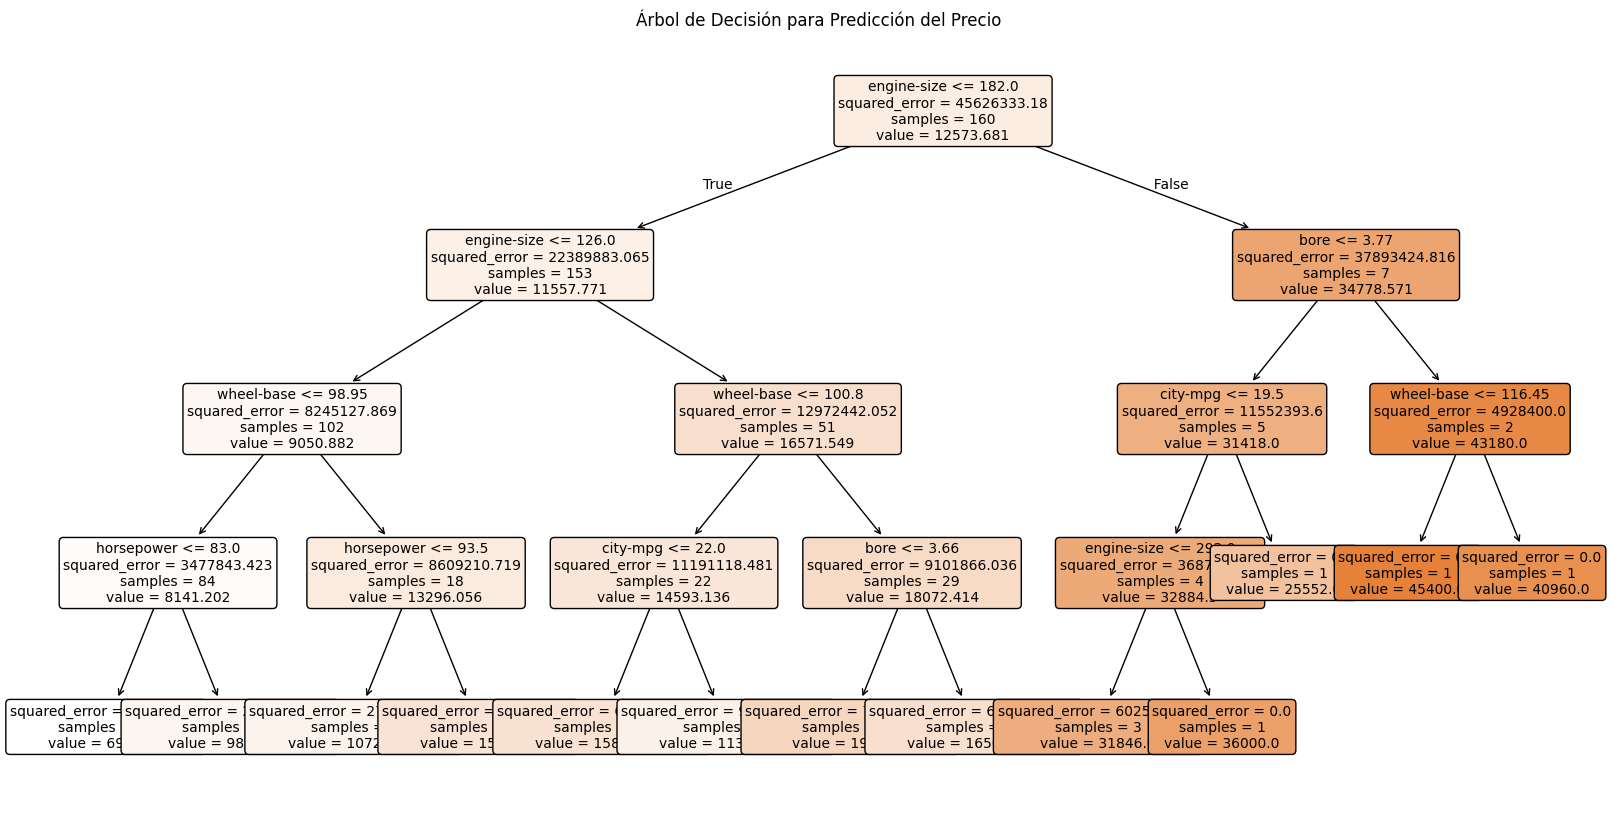

In [11]:
plt.figure(figsize=(20, 10))
plot_tree(tree_model, feature_names=X.columns, filled=True, rounded=True, fontsize=10)
plt.title("Árbol de Decisión para Predicción del Precio")
plt.show()

Error cuadrático medio (MSE): 6207944.08
Coeficiente de determinación (R²): 0.95
RMSE: 2491.57


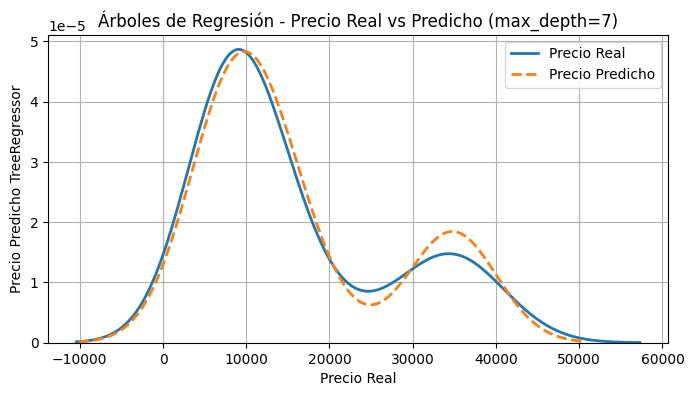

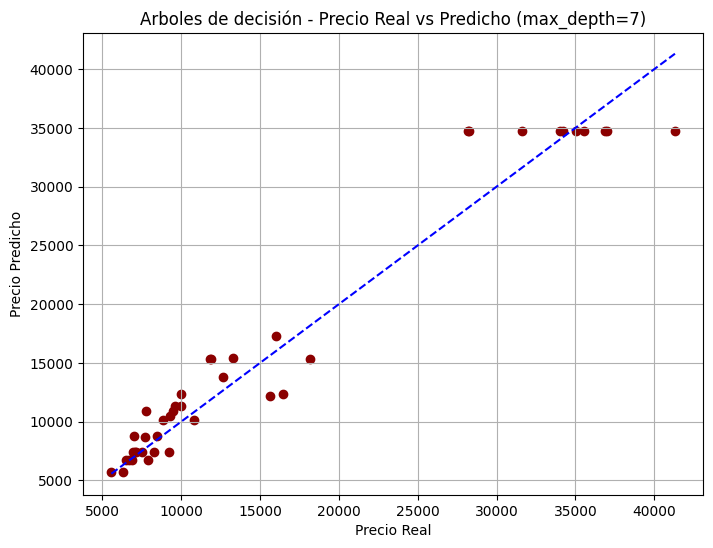

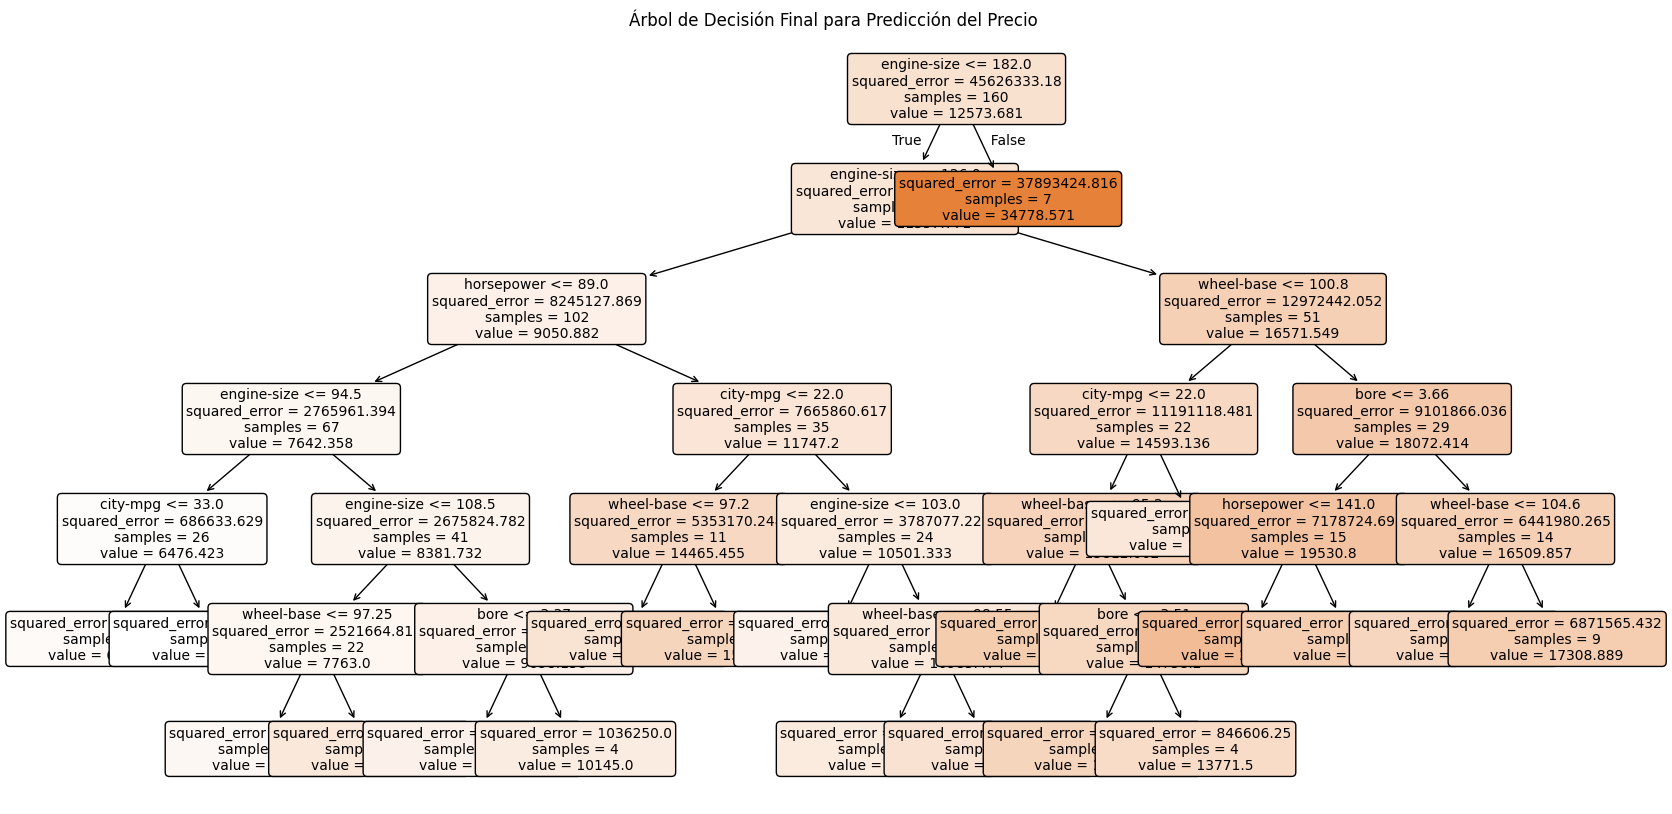

In [12]:

tree_model_7 = DecisionTreeRegressor(
    random_state=42,
    max_depth=7,
    min_samples_split=10,
    min_samples_leaf=2,
    max_features='sqrt',
    max_leaf_nodes=20
)

tree_model_7.fit(X_train, y_train)

y_pred_7 = tree_model_7.predict(X_test)

mse_7 = mean_squared_error(y_test, y_pred_7)
r2_7 = r2_score(y_test, y_pred_7)
rmse_7 = np.sqrt(mse_7)

print(f"Error cuadrático medio (MSE): {mse_7:.2f}")
print(f"Coeficiente de determinación (R²): {r2_7:.2f}")
print(f"RMSE: {rmse_7:.2f}")

plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred_7, label='Precio Predicho', linewidth=2, linestyle='--')
plt.title('Árboles de Regresión - Precio Real vs Predicho (max_depth=7)')
plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho TreeRegressor')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_7, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--')
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Arboles de decisión - Precio Real vs Predicho (max_depth=7)")
plt.grid(True)
plt.show()

plt.figure(figsize=(20, 10))
plot_tree(tree_model_7,
          feature_names=X.columns,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Árbol de Decisión Final para Predicción del Precio")
plt.show()